In [1]:
using KadanoffBaym
using PyPlot
using FFTW, Interpolations
using JLD2
using Tullio

In [2]:
rc("text", usetex=true)
rc("font", family="serif")
rc("text.latex", preamble=raw"\usepackage{amsmath}")
rc("font", size=18)
rc("axes", labelsize=22, titlesize=22)
rc("xtick", labelsize=18)
rc("ytick", labelsize=18)
rc("legend", fontsize=16)

In [5]:
filed = "Data"
pulsed = "Gaussian_sin"
L = 100
T = 0.1
α = 1.0
u = 0.0
γ = 1.0
s = 1.0
ωc = 1.0
t0 = 50.0
ω0 = pi
σ = 2.0
A = 1.0
ti = 3
to = 20
tmax = 200
atol = 1.0e-6
rtol = 1.0e-5

# GG_Jantisymmetric_Gaussian_sin_T0.1_α1.0_s1.0_ωc1.0_t050.0_ω0π_σ2.0_A1.0_ti3_to20_tmax200_atol1.0e-6_rtol1.0e-5

name_p = "T$(T)_α$(α)_s$(s)_ωc$(ωc)_t0$(t0)_ω0$(ω0)_σ$(σ)_A$(A)_ti$(ti)_to$(to)_tmax$(tmax)_atol$(atol)_rtol$(rtol)"

dataL = load("$(filed)/GL_Jantisymmetric_Gaussian_sin_$(name_p).jld2");
dataG = load("$(filed)/GG_Jantisymmetric_Gaussian_sin_$(name_p).jld2");
datats = load("$(filed)/ts_Jantisymmetric_Gaussian_sin_$(name_p).jld2");

GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];

Δk = 2*pi/L
ks = collect(range(-pi, stop=pi-Δk, length=L))

size(GL_data)

(100, 1099, 1099)

In [6]:
ts = ts_data.t;
size(ts)

(1099,)

In [35]:
function ϵ_k(k; u=u, γ=γ)
    u .- 2 * γ * cos.(k)
end

function fermi(ϵ)
    β = 1/T
    1/(exp(β*ϵ)+1)
end

fermi (generic function with 1 method)

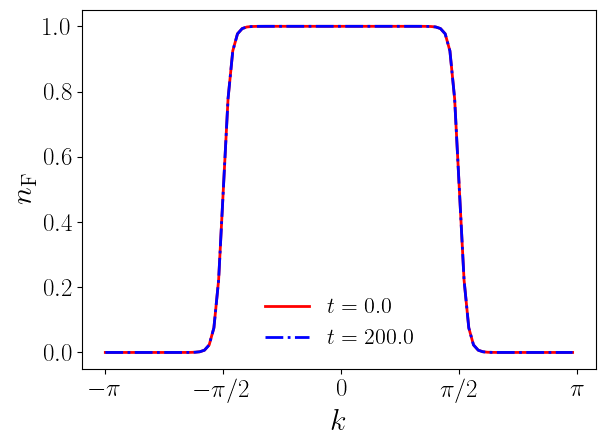

In [8]:
t1 = 1
t2 = length(ts)
sol_t1 = ts[t1]
sol_t2 = ts[t2]
nf_t1  = imag.(GL_data[t1,t1])
nf_t2 = imag.(GL_data[t2,t2])

plot(ks, nf_t1; color="red", linewidth=2, label="\$t = $(round(sol_t1, digits=2))\$", linestyle="-")
plot(ks, nf_t2; color="blue", linewidth=2, label="\$t = $(round(sol_t2, digits=2))\$", linestyle="-.")
xlabel(raw"$k$")
ylabel(raw"$n_{\text{F}}$")
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
legend(frameon=false)
tight_layout()

In [9]:
Nt = length(ts)
T = maximum(ts)
Δ = ts .- ts'

# Windowing function W(t)
W = @. exp(-15 * (Δ^2) / T^2)

GL_filt = similar(GL_data)
GG_filt = similar(GG_data)

for k in 1:size(GL_data,1)
    @views GL_filt[k, :, :] = GL_data[k, :, :] .* W
    @views GG_filt[k, :, :] = GG_data[k, :, :] .* W
end

In [10]:
function wigner_transform_itp(x, ts::Vector; fourier = true, ts_lin = range(first(ts), last(ts); length = length(ts)))
    itp = interpolate((ts, ts), x, Gridded(Linear()))
    return wigner_transform([itp(t1, t2) for t1 in ts_lin, t2 in ts_lin]; ts = ts_lin, fourier = fourier)
end

wigner_transform_itp (generic function with 1 method)

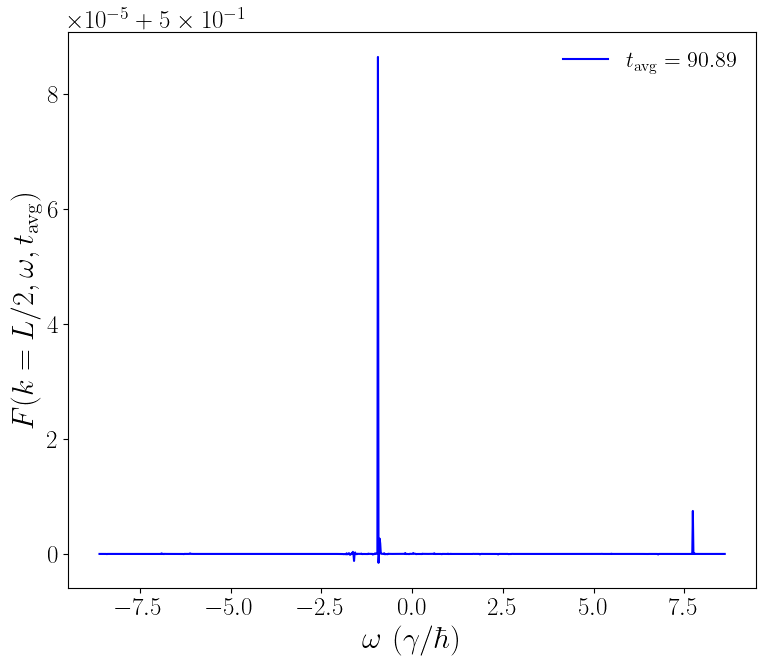

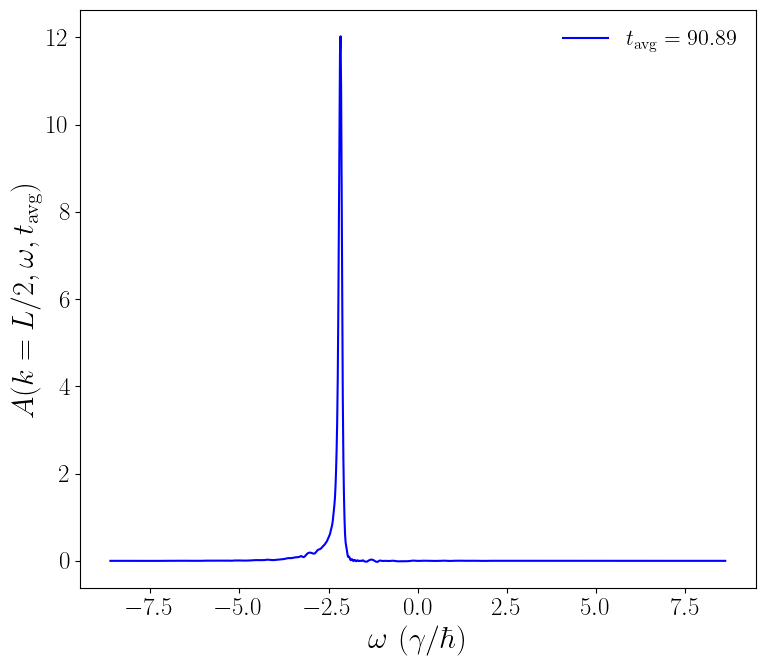

In [12]:
GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp(GL_filt[Int(L/2), :, :], ts; fourier=true)
GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt .- GL_filt)[Int(L/2), :, :], ts; fourier=true)

F_Wigner = - 0.5 * imag(GL_Wigner_FFT) ./ (imag(GR_Wigner_FFT))
A_Wigner = - imag(GR_Wigner_FFT)/pi

t_avg = 500
t_avg_sol = tavg[t_avg]

fig, ax = subplots(figsize=(8,7)) 
xlabel(raw"$\omega \,\, (\gamma/\hbar)$")
ylabel(raw"$F(k=L/2,\omega,t_{\text{avg}})$")
plot(ωs, F_Wigner[:, t_avg], label="\$t_{\\text{avg}} = $(round(t_avg_sol, digits=2))\$", color="blue", linewidth=1.5)
legend(frameon=false)
tight_layout()
# savefig("figura2F.png", dpi=300)

fig, ax = subplots(figsize=(8,7)) 
xlabel(raw"$\omega \,\, (\gamma/\hbar)$")
ylabel("\$ A(k=L/2,\\omega,t_{\\text{avg}})\$")
plot(ωs, A_Wigner[:, t_avg], label="\$t_{\\text{avg}} = $(round(t_avg_sol, digits=2))\$", color="blue", linewidth=1.5)
legend(frameon=false)
tight_layout()
# savefig("figura2F.png", dpi=300)

In [13]:
GL_Wigner_list = []
F_Wigner_list = []
A_Wigner_list = []

tavg_list = []
ωs_list = []

for k in 1:L
    GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp(GL_filt[k, :, :], ts; fourier=true)
    GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt - GL_filt)[k, :, :], ts; fourier=true)
    F_Wigner = - 0.5 * imag(GL_Wigner_FFT) ./ (imag(GR_Wigner_FFT))
    A_Wigner = - imag(GR_Wigner_FFT)/pi

    push!(GL_Wigner_list, GL_Wigner_FFT)
    push!(F_Wigner_list, F_Wigner)
    push!(A_Wigner_list, A_Wigner)
    
    push!(tavg_list, tavg)
    push!(ωs_list, ωs)
end

In [14]:
dim_tavg = size(GL_data)[2]

GL_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
F_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
A_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)

for i in 1:L
    for k in 1:dim_tavg
        for j in 1:dim_tavg
            GL_Wigner_tensor[i,j,k] = GL_Wigner_list[i][j,k]
            F_Wigner_tensor[i,j,k] = F_Wigner_list[i][j,k]
            A_Wigner_tensor[i,j,k] = A_Wigner_list[i][j,k]
        end
    end
end

In [15]:
@tullio GL_Wigner_sumk[i_ωs,i_tavg] := GL_Wigner_tensor[k,i_ωs,i_tavg];
@tullio A_Wigner_sumk[i_ωs,i_tavg] := A_Wigner_tensor[k,i_ωs,i_tavg];

GL_Wigner_sumk = GL_Wigner_sumk./L
A_Wigner_sumk = A_Wigner_sumk./L
F_Wigner_sumk = (1/(2pi)) * imag.(GL_Wigner_sumk) ./ A_Wigner_sumk;

54.462659380692166


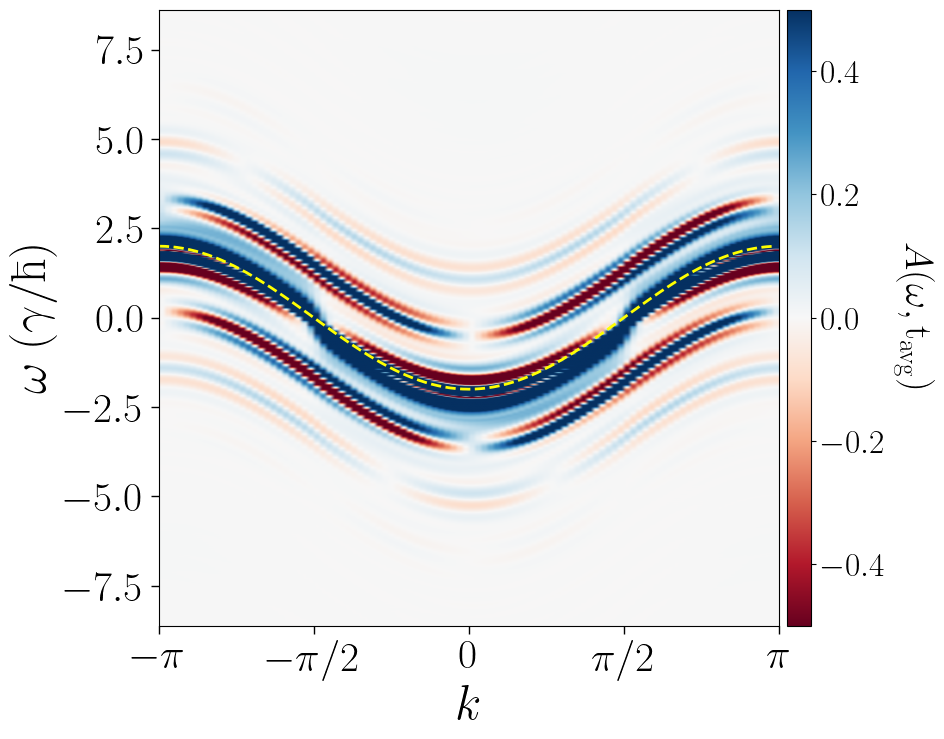

In [56]:
fig,axs=plt.subplots(1,1,figsize=(8,8))

# t_avg1 = 210
# t_avg2 = 499
# t_avg3 = 504
# t_avg4 = 602

fs = 30
t_avg = 300
t_avg_sol = tavg[t_avg]
println(t_avg_sol)

cmap = plt.get_cmap("RdBu", 3024)

datt = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg]))

t1x = -pi
t2x = pi
t1y = ωs[1]
t2y = ωs[end]

im = axs.imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-0.5, vmax=0.5)

axs.set_xlabel(raw"$k$", fontsize=fs+5)
axs.set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$", fontsize=fs+5)
axs.tick_params(axis="both", which="both", labelsize=fs, direction="out", length=6, width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1, 2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
plt.plot(ks, ϵ_k.(ks), color="yellow", ls="--", linewidth=2)
box = axs.get_position() 
cbar_ax = fig.add_axes([box.x1 + 0.01, box.y0, 0.03, box.height])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=fs-6)
cbar.set_label(raw"$A\mathrm{(\omega,t_{\text{avg}})}$", fontsize=fs-2,rotation=270,labelpad=35)
# plt.savefig("Atest.png",bbox_inches="tight")

5.2823315118397085


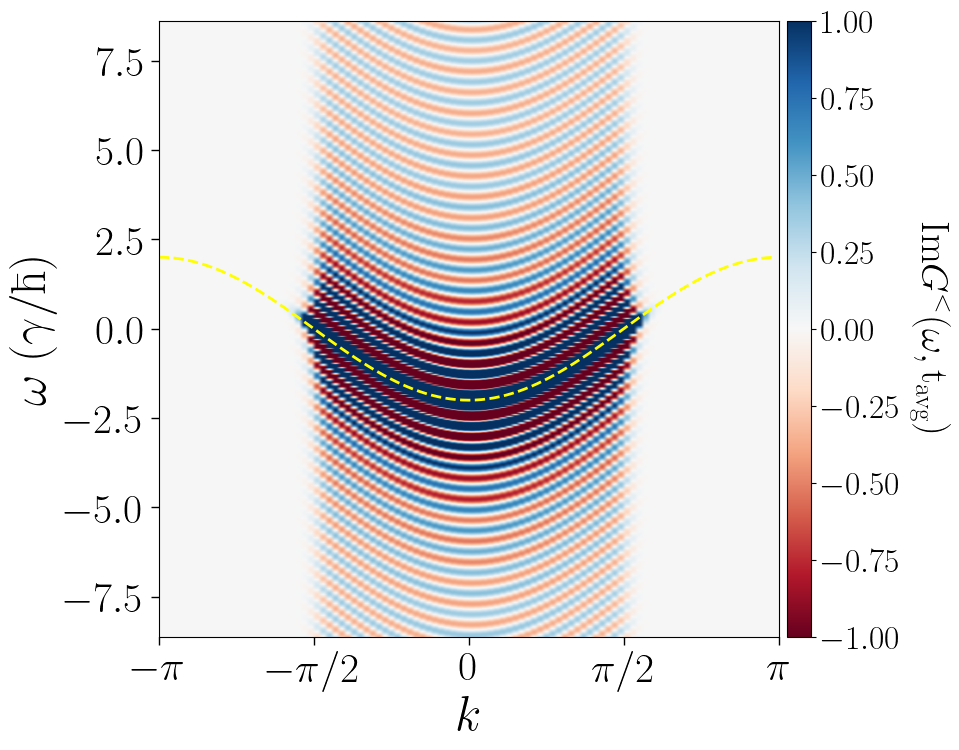

In [26]:
fig,axs=plt.subplots(1,1,figsize=(8,8))

fs = 30
t_avg = 30
t_avg_sol = tavg[t_avg]

println(t_avg_sol)

cmap = plt.get_cmap("RdBu", 3024)

datt = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg]))

t1x = -pi
t2x = pi
t1y = ωs[1]
t2y = ωs[end]

im = axs.imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)

axs.set_xlabel(raw"$k$", fontsize=fs+5)
axs.set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$", fontsize=fs+5)
axs.tick_params(axis="both", which="both", labelsize=fs, direction="out", length=6, width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1, 2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
plt.plot(ks, ϵ_k.(ks), color="yellow", ls="--", linewidth=2)

box = axs.get_position() 
cbar_ax = fig.add_axes([box.x1 + 0.01, box.y0, 0.03, box.height])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=fs-6)
cbar.set_label(raw"$\text{Im}G^{<}\mathrm{(\omega,t_{\text{avg}})}$", fontsize=fs-2,rotation=270,labelpad=35)
# plt.savefig("Atest.png",bbox_inches="tight")

54.462659380692166


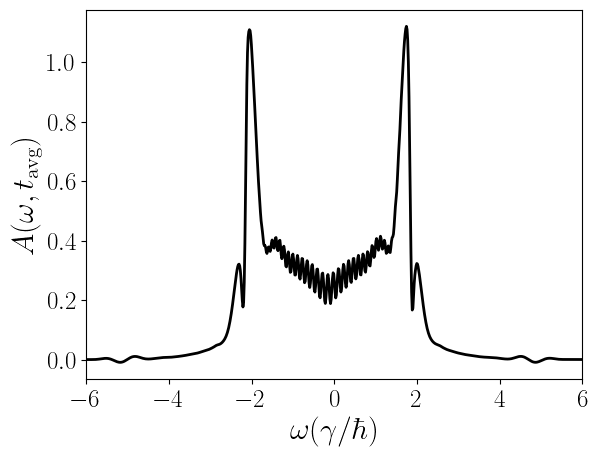

In [30]:
t_avg = 300
t_avg_sol = tavg[t_avg]

plot(ωs, real.(A_Wigner_sumk[:,t_avg]), color="black", linewidth=2)
xlabel(raw"$\omega(\gamma/\hbar)$")
ylabel(raw"$A(\omega,t_{\text{avg}})$")
println(t_avg_sol)
plt.xlim(-6,6)
#plt.ylim(0,0.05)
plt.show()

54.462659380692166


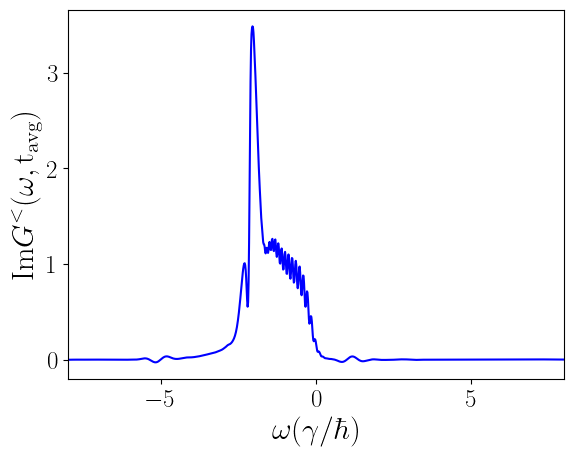

In [33]:
t_avg = 300
t_avg_sol = tavg[t_avg]

plot(ωs, imag.(GL_Wigner_sumk[:,t_avg]), color="blue", linewidth=1.5)
xlabel(raw"$\omega(\gamma/\hbar)$")
ylabel(raw"$\text{Im}G^{<}\mathrm{(\omega,t_{\text{avg}})}$")
plt.xlim(-8,8)
#plt.ylim(0,0.1)
println(t_avg_sol)
plt.show()

36.247723132969035


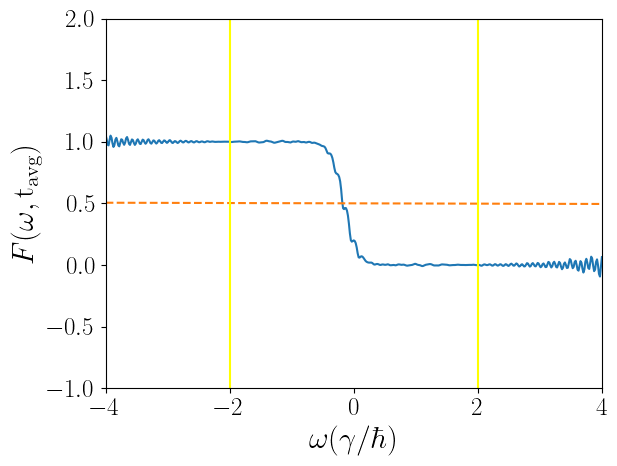

PyObject Text(41.51321041645047, 0.5, '$F\\mathrm{(\\omega,t_{\\text{avg}})}$')

In [52]:
t_avg = 200
t_avg_sol = tavg[t_avg]
println(t_avg_sol)
δ = 1e-6
A_col   = real.(A_Wigner_sumk[:, t_avg])
GL_im   = imag.(GL_Wigner_sumk[:, t_avg])/pi
# Máscara de puntos "seguros"
mask = abs.(A_col) .> δ
ratio = fill(NaN, length(A_col))
ratio[mask] .= GL_im[mask] ./ A_col[mask]

plt.plot(ωs,ratio)
plt.plot(ωs,fermi.(ωs),ls="--")
plt.xlim(-4,4)
plt.ylim(-1,2)
plt.axvline(2,color="yellow")
plt.axvline(-2,color="yellow")


#plt.xlim(-5.2,5.2)
xlabel(raw"$\omega(\gamma/\hbar)$")
ylabel(raw"$F\mathrm{(\omega,t_{\text{avg}})}$")

sys:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


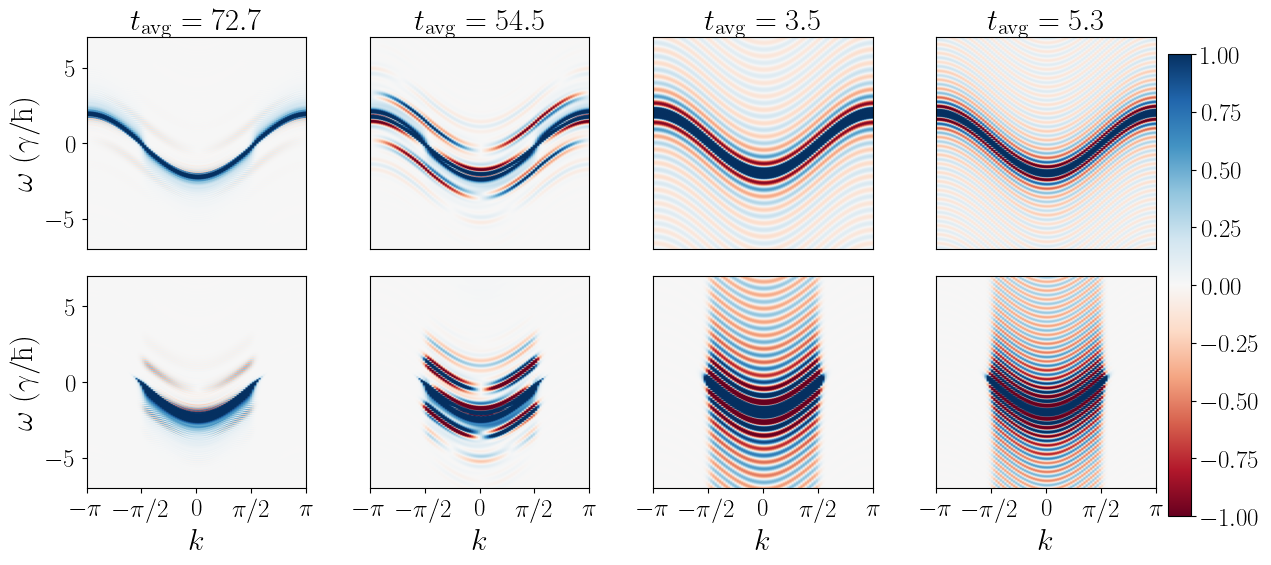

In [55]:
fig, axs = subplots(2, 4, figsize=(12, 6))

cmap = plt.get_cmap("RdBu", 3024)

t1x = -pi
t2x = pi
t1y = ωs[1]
t2y = ωs[end]

t_avg1 = 400
t_avg2 = 300
t_avg3 = 20
t_avg4 = 30


datt1 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg1]))
datt2 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg2]))
datt3 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg3]))
datt4 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg4]))

datt5 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg1]))
datt6 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg2]))
datt7 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg3]))
datt8 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg4]))

img1 = axs[1,1].imshow(datt1, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img2 = axs[1,2].imshow(datt2, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img3 = axs[1,3].imshow(datt3, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img4 = axs[1,4].imshow(datt4, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)

img5 = axs[2,1].imshow(datt5, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img6 = axs[2,2].imshow(datt6, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img7 = axs[2,3].imshow(datt7, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img8 = axs[2,4].imshow(datt8, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)

axs[1,1].set_title("\$t_{\\text{avg}} = $(round(tavg[t_avg1], digits=1))\$")
axs[1,2].set_title("\$t_{\\text{avg}} = $(round(tavg[t_avg2], digits=1))\$")
axs[1,3].set_title("\$t_{\\text{avg}} = $(round(tavg[t_avg3], digits=1))\$")
axs[1,4].set_title("\$t_{\\text{avg}} = $(round(tavg[t_avg4], digits=1))\$")

axs[1,1].set_xticks([])
axs[1,2].set_xticks([])
axs[1,3].set_xticks([])
axs[1,4].set_xticks([])

axs[1,2].set_yticks([])
axs[1,3].set_yticks([])
axs[1,4].set_yticks([])
axs[2,2].set_yticks([])
axs[2,3].set_yticks([])
axs[2,4].set_yticks([])

axs[2,1].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
axs[2,2].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
axs[2,3].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
axs[2,4].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])


axs[2,1].set_xlabel(raw"$k$")
axs[2,2].set_xlabel(raw"$k$")
axs[2,3].set_xlabel(raw"$k$")
axs[2,4].set_xlabel(raw"$k$")

axs[1,1].set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$")
axs[2,1].set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$")

for ax in vec(axs)
    ax.set_ylim(-7,7)  
end

fig.subplots_adjust(right=1.14)    # mueve toda la grilla a la izquierda
fig.colorbar(img1, ax=vec(axs), location="right", pad=0.10)
fig.tight_layout()
#savefig("panel_α0.0_4x2.png", dpi=200)